In [1]:
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import polars as pl
import colorir as cl
import numpy as np
from analyses.parse import parse_cells_multiple

In [21]:
sim_paths = {}
for path in Path("../runs/speed/").iterdir():
    sim_type = path.name
    gamma = 20 - int(sim_type.split("-")[1])
    for replica_path in path.iterdir():
        replica = int(replica_path.name)
        sim_paths[(gamma, replica)] = replica_path

In [22]:
sims = parse_cells_multiple(sim_paths.values(), 30)

In [23]:
sim_ids = list(sim_paths.keys())
for i in range(len(sims)):
    sims[i] = sims[i].with_columns(
        gamma=sim_ids[i][0], 
        sim_replica=sim_ids[i][1]
    )
celldf = pl.concat(sims)
celldf = celldf.with_columns(
    displ=(pl.col("center_x") ** 2 + pl.col("center_y") ** 2) ** 0.5
)

In [24]:
grouppers = ["gamma", "sim_replica", "wtime"]
displdf = celldf.group_by(grouppers).agg(
    cluster_x=pl.col("center_x").mean(),
    cluster_y=pl.col("center_y").mean(),
    mean_displ=pl.col("displ").mean(),
    med_displ=pl.col("displ").median()
).sort(grouppers)
displdf

gamma,sim_replica,wtime,cluster_x,cluster_y,mean_displ,med_displ
i32,i32,i32,f32,f32,f32,f32
0,0,0,433.300049,433.299988,614.067871,615.056519
0,0,100000,374.361847,362.397461,530.212097,546.781738
0,0,200000,318.912354,323.1073,474.199799,478.11142
0,0,300000,287.697052,289.229279,430.144165,467.157349
0,0,400000,280.46048,275.529236,425.530945,445.333221
…,…,…,…,…,…,…
20,4,14500000,77.122459,74.833153,116.028175,122.764511
20,4,14600000,82.664749,79.359482,121.106537,124.670845
20,4,14700000,89.211922,73.46209,122.026901,123.379669


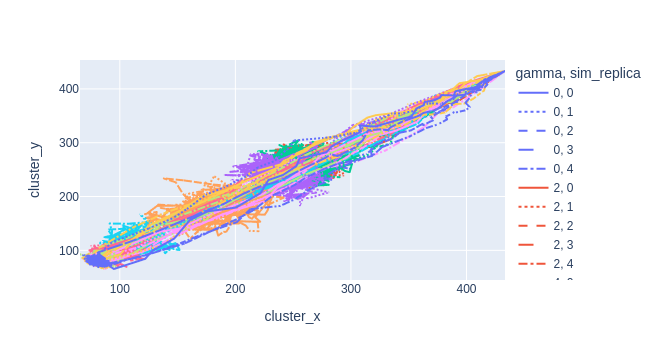

In [25]:
# Cluster trajectories
px.line(
    displdf,
    x="cluster_x",
    y="cluster_y",
    color="gamma",
    line_dash="sim_replica"
)

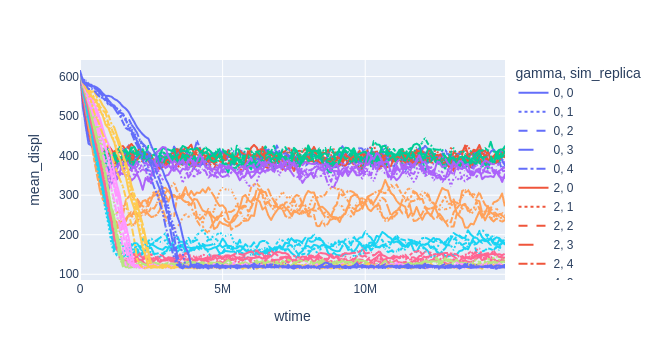

In [26]:
px.line(
    displdf,
    x="wtime",
    y="mean_displ",
    color="gamma",
    line_dash="sim_replica"
)

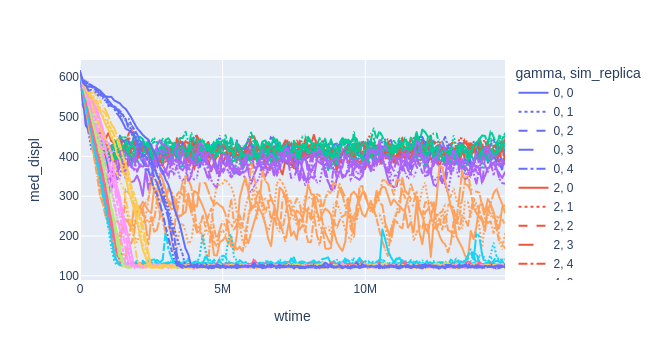

In [27]:
px.line(
    displdf,
    x="wtime",
    y="med_displ",
    color="gamma",
    line_dash="sim_replica"
)

In [28]:
repldf = displdf.group_by(["gamma", "wtime"]).agg(
    med_med=pl.col("med_displ").median(),
    med_mean=pl.col("med_displ").mean(),
    med_min=pl.col("med_displ").min(),
    med_max=pl.col("med_displ").max(),
    mean_mean=pl.col("mean_displ").mean(),
    mean_med=pl.col("mean_displ").median(),
    mean_min=pl.col("mean_displ").min(),
    mean_max=pl.col("mean_displ").max(),
).sort(["gamma", "wtime"])
repldf

gamma,wtime,med_med,med_mean,med_min,med_max,mean_mean,mean_med,mean_min,mean_max
i32,i32,f32,f32,f32,f32,f32,f32,f32,f32
0,0,615.056519,615.056519,615.056519,615.056519,614.067871,614.067871,614.067871,614.067993
0,100000,536.782532,537.724731,528.370239,546.781738,528.337341,530.212097,521.556396,534.718506
0,200000,498.899963,493.850891,478.11142,500.450867,481.424316,482.607727,474.199799,488.611176
0,300000,467.157349,465.389404,458.508728,473.991516,442.056885,443.143951,430.144165,451.102112
0,400000,445.123291,439.624664,416.558777,447.097595,427.604736,428.804565,422.975983,430.508698
…,…,…,…,…,…,…,…,…,…
20,14500000,122.293686,122.003311,120.38105,123.304123,117.562767,118.326614,115.148811,119.221054
20,14600000,124.670845,122.635887,117.901688,125.459671,119.133034,120.730263,114.031639,122.338379
20,14700000,120.881912,121.953514,119.597107,126.012596,118.925034,117.912323,116.242958,122.15612


/tmp/ipykernel_1774232/1739442699.py:3: FutureWarning:

'config.DEFAULT_PALETTES_DIR' is going to change to the current directory on the next minor release, specify 'palettes_dir=colorir.config.USR_PALETTES_DIR' to disable this warning



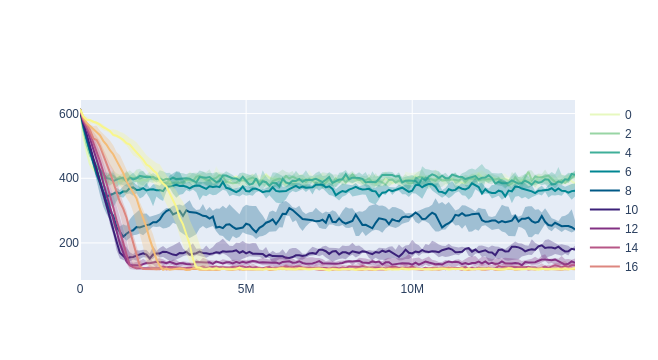

In [29]:
import random as rand

palette = cl.Grad(cl.StackPalette.load("carnival"), domain=[0, 20])
fig = go.Figure()
for gamma, group in repldf.group_by("gamma"):
    gamma = gamma[0]
    fig.add_trace(go.Scatter(
        x=group["wtime"],
        y=group["mean_med"],
        line_color=palette(gamma),
        name=gamma
    ))
    fig.add_trace(go.Scatter(
        x=pl.concat([group["wtime"], group["wtime"][::-1]]),
        y=pl.concat([group["mean_min"], group["mean_max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor=palette(gamma),
        opacity=0.3,
        showlegend=False
    ))
fig

In [30]:
concdf = displdf.filter(pl.col("wtime") > 10e6).group_by(["gamma"]).agg(
    med=pl.col("mean_displ").median(),
    min=pl.col("mean_displ").min(),
    max=pl.col("mean_displ").max(),
)
concdf

gamma,med,min,max
i32,f32,f32,f32
0,394.49118,360.31073,428.470856
2,396.237885,361.216217,427.734467
4,396.484467,354.667816,444.372894
6,364.045074,322.777588,407.120911
8,269.016846,217.816711,338.347137
…,…,…,…
12,139.383881,124.153564,165.040268
14,123.359787,114.844238,144.442886
16,119.1334,113.931862,129.960297


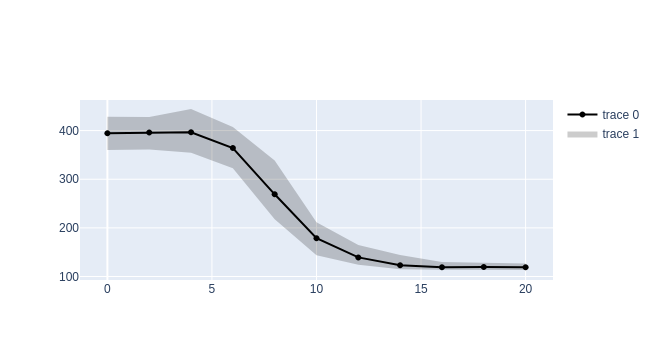

In [31]:
fig = go.Figure([
    go.Scatter(
        x=concdf["gamma"],
        y=concdf["med"],
        line_color="black"
    ),
    go.Scatter(
        x=pl.concat([concdf["gamma"], concdf["gamma"][::-1]]),
        y=pl.concat([concdf["min"], concdf["max"][::-1]]),
        fill="toself",
        line_color="rgba(0, 0, 0, 0)",
        fillcolor="rgba(0, 0, 0, 0.2)"
    )
])
fig

In [32]:
filterdf = celldf\
    .join(displdf, on=["gamma", "sim_replica", "wtime"])\
    .group_by("gamma")\
    .agg(
        pl.col("*").filter(
            pl.col("wtime") > 0.25e6,
            pl.col("wtime") < pl.col("wtime").filter(pl.col("mean_displ") <= pl.col("mean_displ").filter(pl.col("wtime") > 1e7).mean()).min()
        )
    )\
    .explode(pl.exclude("gamma"))\
    .sort(["gamma", "sim_replica", "wtime"])
filterdf

gamma,index,ancestor,area,target_area,perimeter,target_perimeter,center_x,center_y,chem_center_x,chem_center_y,chem_mass,ligands,receptors,wtime,sim_replica,displ,cluster_x,cluster_y,mean_displ,med_displ
i32,u32,u32,u32,u32,u32,u32,f32,f32,f32,f32,u32,u64,u64,i32,i32,f32,f32,f32,f32,f32
0,1,1,200,200,180,180,291.030426,93.899796,291.03064,93.898453,80424,187,197,300000,0,305.80368,287.697052,289.229279,430.144165,467.157349
0,42,42,200,200,182,180,439.849091,436.875214,439.699188,436.772644,17608,84,39,300000,0,619.941284,287.697052,289.229279,430.144165,467.157349
0,2,2,200,200,178,180,176.760239,330.233276,176.720901,330.183167,66686,59,26,300000,0,374.564026,287.697052,289.229279,430.144165,467.157349
0,99,99,200,200,184,180,103.402252,95.603683,103.387161,95.568398,113424,104,250,300000,0,140.826447,287.697052,289.229279,430.144165,467.157349
0,98,98,200,200,184,180,407.263855,255.159042,407.109863,255.078003,45476,190,143,300000,0,480.593353,287.697052,289.229279,430.144165,467.157349
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
20,5,5,200,200,182,180,98.349213,145.60463,98.29155,145.584015,106455,34,184,3400000,4,175.707932,91.643089,71.863228,123.529892,125.507339
20,0,0,200,200,188,180,6.897346,88.534157,6.89444,88.484802,123841,40,78,3400000,4,88.802422,91.643089,71.863228,123.529892,125.507339
20,64,64,201,200,186,180,132.951797,101.024323,132.924408,101.007217,108740,24,245,3400000,4,166.979324,91.643089,71.863228,123.529892,125.507339


In [33]:
def circmean(expr):
    return pl.arctan2(expr.sin().sum(), expr.cos().sum())


cellveldf = filterdf\
    .sort("wtime")\
    .group_by(["gamma", "sim_replica", "index"])\
    .agg(
        vel=pl.col("displ").diff().abs().mean(),
        arc=circmean(pl.arctan2(
            pl.col("center_y").diff(), 
            pl.col("center_x").diff()
        ))
)
cellveldf

gamma,sim_replica,index,vel,arc
i32,i32,u32,f32,f32
16,3,53,36.646549,-2.313591
4,1,11,54.488708,-1.658025
18,4,94,32.897179,-2.417001
20,2,62,17.919115,-2.311193
2,1,24,30.491568,2.070373
…,…,…,…,…
16,0,59,30.49596,-1.999997
20,2,81,20.648237,-2.214191
8,0,60,43.533665,-2.704331


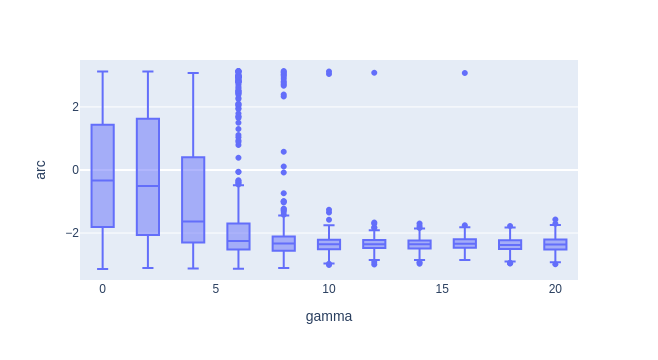

In [34]:
px.box(cellveldf, x="gamma", y="arc").update_layout(width=600)

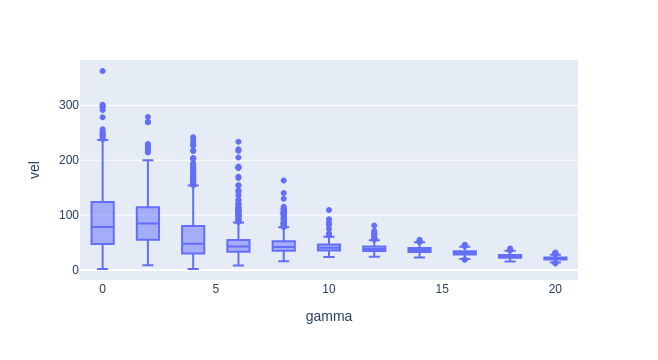

In [35]:
px.box(cellveldf, x="gamma", y="vel").update_layout(width=600)

In [36]:
angles = pl.arctan2(
    pl.col("cluster_y").diff(),
    pl.col("cluster_x").diff()
) - pl.arctan2(
    -pl.col("cluster_y"),
    -pl.col("cluster_x")
)
angles_wrapped = (angles + np.pi) % (2 * np.pi) - np.pi

clusterveldf = filterdf\
    .group_by(["gamma", "sim_replica", "wtime"])\
    .agg(
        pl.col("mean_displ").first(),
        pl.col("cluster_x").first(),
        pl.col("cluster_y").first()
    )\
    .sort("wtime")\
    .group_by(["gamma", "sim_replica"])\
    .agg(
        vel=pl.col("mean_displ")\
            .diff()\
            .abs()\
            .mean(),
        arc=circmean(pl.arctan2(
            pl.col("cluster_y").diff(), 
            pl.col("cluster_x").diff()
        )),
        align=(angles_wrapped.cos().mean() ** 2 + angles_wrapped.sin().mean() ** 2).sqrt()
    )
clusterveldf

gamma,sim_replica,vel,arc,align
i32,i32,f32,f32,f32
4,2,25.45842,-2.302426,0.999117
8,3,33.914791,-2.386036,0.974982
12,1,32.605511,-2.318579,0.979259
16,4,31.583698,-2.389007,0.981394
12,4,35.027302,-2.328201,0.975053
…,…,…,…,…
12,0,34.743233,-2.358364,0.987337
18,1,19.436296,-2.319568,0.955942
18,3,17.576439,-2.403161,0.892485


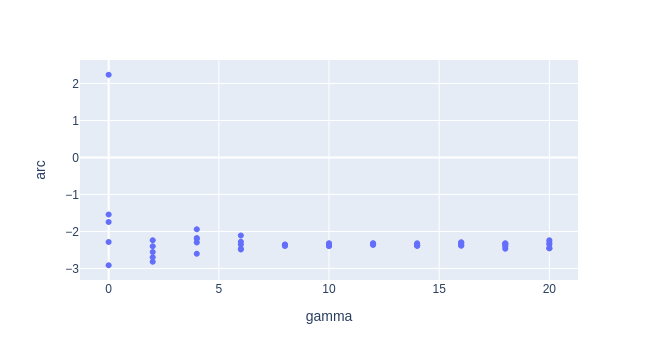

In [37]:
px.scatter(clusterveldf, x="gamma", y="arc").update_layout(width=600)

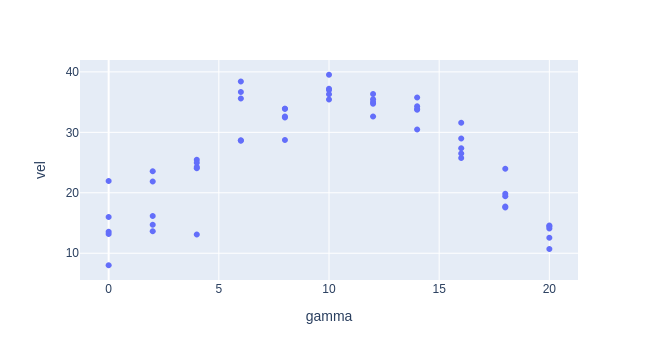

In [38]:
px.scatter(clusterveldf, x="gamma", y="vel").update_layout(width=600)

In [39]:
veldf = cellveldf.join(
    clusterveldf, 
    ["gamma", "sim_replica"],
    suffix="_cluster"
).group_by("gamma").agg(
    mean_vel=pl.col("vel").mean(),
    mean_vel_cluster=pl.col("vel_cluster").mean()
)
veldf

gamma,mean_vel,mean_vel_cluster
i32,f32,f32
6,50.324291,33.589848
10,42.014515,37.084785
8,47.254852,32.330254
12,39.254456,34.842014
18,25.117126,19.721045
…,…,…
4,63.215351,22.360308
0,90.561401,14.545335
2,89.30867,17.983137


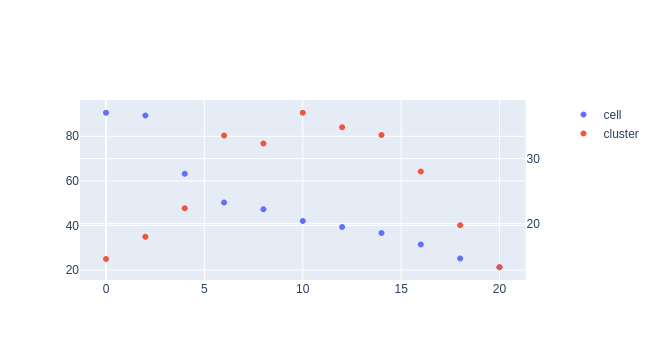

In [40]:
# Non-linear relationship between cell speed and cluster speed
# Or it is linear but strength of CIL depends on gamma? 
fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_vel"],
    mode="markers",
    name="cell"
))
fig.add_trace(go.Scatter(
    x=veldf["gamma"],
    y=veldf["mean_vel_cluster"],
    mode="markers",
    name="cluster"
), secondary_y=True)

In [47]:
displ_cuts = np.linspace(0, (2 * 500 ** 2) ** 0.5, 8)
time_cuts = np.arange(0, celldf["wtime"].max() + 2e6, 2e6)

angles = pl.arctan2(
    pl.col("center_y").diff(),
    pl.col("center_x").diff()
) - pl.arctan2(
    -pl.col("center_y"),
    -pl.col("center_x")
)
angles_wrapped = (angles + np.pi) % (2 * np.pi) - np.pi

arcdf = celldf\
    .filter(pl.col("wtime") > 1e7)\
    .with_columns(
        q_displ=pl.col("displ")\
            .cut(
                displ_cuts[1:],
                labels=displ_cuts.astype(str)
            )\
            .cast(str)
            .cast(pl.Float64),
        q_time=pl.col("wtime")\
            .cut(
                time_cuts[1:],
                labels=time_cuts.astype(str)
            )\
            .cast(str)
            .cast(pl.Float64)
    )\
    .sort("wtime")\
    .group_by(["gamma", "sim_replica", "index", "q_time"])\
    .agg(
        n_times=pl.col("wtime").n_unique(),
        arc=circmean(pl.arctan2(
            pl.col("center_y").diff(), 
            pl.col("center_x").diff()
        )),
        align=(angles_wrapped.cos().mean() ** 2 + angles_wrapped.sin().mean() ** 2).sqrt()
    )\
    .sort(["gamma", "sim_replica", "index", "q_time"])
arcdf

gamma,sim_replica,index,q_time,n_times,arc,align
i32,i32,u32,f64,u32,f32,f32
0,0,0,1e7,20,-2.421826,0.090938
0,0,0,1.2e7,20,-0.133776,0.183048
0,0,0,1.4e7,9,-0.787795,0.222696
0,0,1,1e7,20,-1.50954,0.101765
0,0,1,1.2e7,20,-0.488013,0.318979
…,…,…,…,…,…,…
20,4,98,1.2e7,20,0.778094,0.222002
20,4,98,1.4e7,9,-0.968979,0.268137
20,4,99,1e7,20,-1.6959,0.151289


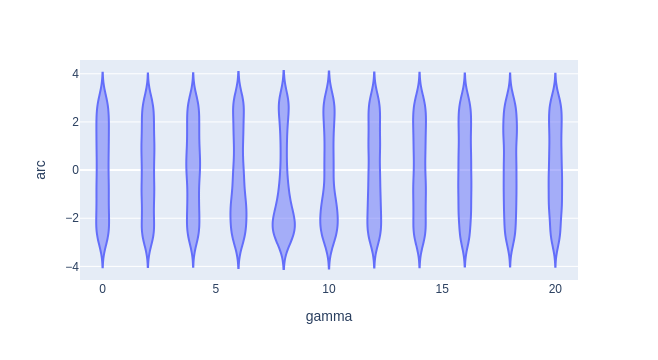

In [48]:
px.violin(
    arcdf,
    x="gamma",
    y="arc",
    width=1200
)

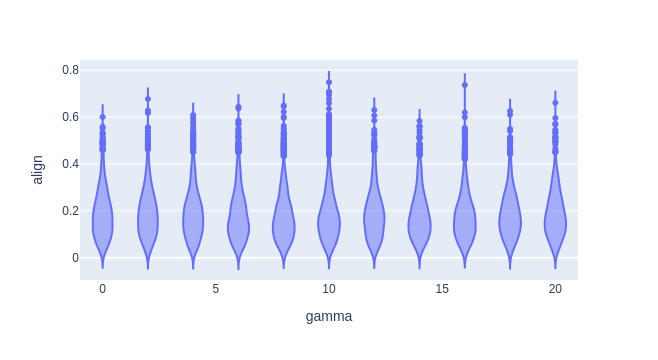

In [49]:
px.violin(
    arcdf,
    x="gamma",
    y="align",
    width=1200
)